In [1]:
import pandas as pd
from pathlib import Path
import re

# ============================================================
# PATHS
# ============================================================
EU = Path("/user/ab5405/summeraliaclimate/code/energy_uncertainty")

NEW_STER = EU / "data" / "regression" / "sters"
ORIG_STER = EU / "output_original/sters"

# ============================================================
# DIAGNOSTIC FUNCTIONS
# ============================================================
def analyze_coefficients(coef_file: Path):
    """Analyze a coefficient file to determine specification"""
    
    if not coef_file.exists():
        print(f"  ❌ File not found: {coef_file}")
        return None
    
    df = pd.read_csv(coef_file)
    df["parm"] = df["parm"].str.strip()
    
    print(f"\n{'='*70}")
    print(f"FILE: {coef_file.name}")
    print(f"{'='*70}")
    print(f"Total coefficients: {len(df)}")
    
    # Check for suffixes
    suffixes = set()
    for parm in df["parm"]:
        if "_GMFD" in parm:
            suffixes.add("_GMFD")
        if "_ERA5" in parm:
            suffixes.add("_ERA5")
        if "_JRA" in parm:
            suffixes.add("_JRA")
        if "_MERRA" in parm:
            suffixes.add("_MERRA")
    
    if suffixes:
        print(f"Suffixes found: {', '.join(sorted(suffixes))}")
    else:
        print("Suffixes: NONE (unsuffixed variables)")
    
    # Check temperature polynomial order
    temp_orders = set()
    for parm in df["parm"]:
        match = re.search(r"FD_temp(\d+)", parm)
        if match:
            temp_orders.add(int(match.group(1)))
    
    if temp_orders:
        max_temp_order = max(temp_orders)
        print(f"Temperature polynomial orders: {sorted(temp_orders)} (max={max_temp_order})")
    else:
        print("Temperature terms: NONE FOUND")
        max_temp_order = 0
    
    # Check for climate interactions
    has_cdd = any("FD_cdd20_TINV" in parm for parm in df["parm"])
    has_hdd = any("FD_hdd20_TINV" in parm for parm in df["parm"])
    print(f"Climate interactions: CDD={has_cdd}, HDD={has_hdd}")
    
    # Check for income interactions
    has_income_spline = any("FD_dc1_lgdppc_MA15" in parm for parm in df["parm"])
    has_income_lr = any("FD_I" in parm and "lgdppc_MA15" in parm for parm in df["parm"])
    has_income_dum = any("DumIncG" in parm for parm in df["parm"])
    print(f"Income interactions: spline={has_income_spline}, long-run={has_income_lr}, dummies={has_income_dum}")
    
    # Check for year interactions
    has_year_linear = any("FD_yeartemp" in parm and "year2" not in parm for parm in df["parm"])
    has_year_quad = any("FD_year2temp" in parm for parm in df["parm"])
    print(f"Year interactions: linear={has_year_linear}, quadratic={has_year_quad}")
    
    # Check for precip
    has_precip = any("FD_precip" in parm for parm in df["parm"])
    print(f"Precipitation terms: {has_precip}")
    
    # Determine specification
    print(f"\n{'─'*70}")
    if max_temp_order == 4 and not (has_cdd or has_hdd or has_income_spline or has_year_linear):
        spec_type = "GLOBAL (simple 4th order)"
    elif max_temp_order == 2 and (has_cdd or has_hdd or has_income_spline):
        if has_year_quad:
            spec_type = "INTERACTED (quadinter)"
        elif has_year_linear:
            spec_type = "INTERACTED (lininter)"
        else:
            spec_type = "INTERACTED (base)"
    elif max_temp_order > 0:
        spec_type = f"UNKNOWN (temp^{max_temp_order} with mixed interactions)"
    else:
        spec_type = "UNKNOWN (no temp terms found)"
    
    print(f"SPECIFICATION: {spec_type}")
    print(f"{'─'*70}")
    
    # Show sample coefficients
    print(f"\nSample coefficients (first 20):")
    print(df.head(20).to_string(index=False))
    
    # Show temp coefficients specifically
    temp_coefs = df[df["parm"].str.contains("FD_temp", na=False)]
    if len(temp_coefs) > 0:
        print(f"\nAll temperature coefficients ({len(temp_coefs)} total):")
        print(temp_coefs.to_string(index=False))
    
    return {
        'n_coef': len(df),
        'suffixes': list(suffixes),
        'max_temp_order': max_temp_order,
        'has_climate': has_cdd or has_hdd,
        'has_income': has_income_spline or has_income_lr,
        'has_year': has_year_linear or has_year_quad,
        'spec_type': spec_type
    }

# ============================================================
# ANALYZE ALL FILES
# ============================================================
print("\n" + "="*70)
print("ANALYZING YOUR NEW COEFFICIENT FILES")
print("="*70)

new_files = {
    "GMFD interacted": NEW_STER / "FD_FGLS_inter_TINV_clim_quadinter_GMFD_coeff.csv",
    "ERA5 interacted": NEW_STER / "FD_FGLS_inter_TINV_clim_quadinter_ERA5_coeff.csv",
    "JRA_3Q interacted": NEW_STER / "FD_FGLS_inter_TINV_clim_quadinter_JRA_3Q_coeff.csv",
    "MERRA2 interacted": NEW_STER / "FD_FGLS_inter_TINV_clim_quadinter_MERRA2_coeff.csv",
    "GMFD global": NEW_STER / "FD_FGLS_global_TINV_clim_GMFD_coeff.csv",
}

new_results = {}
for name, path in new_files.items():
    new_results[name] = analyze_coefficients(path)

print("\n" + "="*70)
print("ANALYZING ORIGINAL COEFFICIENT FILES")
print("="*70)

orig_files = {
    "Original interacted": ORIG_STER / "FD_FGLS_inter_TINV_clim_quadinter_coeff.csv",
    "Original global": ORIG_STER / "FD_FGLS_global_TINV_clim_coeff.csv",
}

orig_results = {}
for name, path in orig_files.items():
    orig_results[name] = analyze_coefficients(path)

# ============================================================
# SUMMARY COMPARISON
# ============================================================
print("\n" + "="*70)
print("SUMMARY COMPARISON")
print("="*70)

summary_data = []
for name, res in {**new_results, **orig_results}.items():
    if res is not None:
        summary_data.append({
            'File': name,
            'N_coef': res['n_coef'],
            'Max_temp_order': res['max_temp_order'],
            'Climate': 'Yes' if res['has_climate'] else 'No',
            'Income': 'Yes' if res['has_income'] else 'No',
            'Year': 'Yes' if res['has_year'] else 'No',
            'Spec': res['spec_type']
        })

if summary_data:
    summary_df = pd.DataFrame(summary_data)
    print(summary_df.to_string(index=False))
    
    # Save summary
    outfile = EU / "figures" / "comparison" / "coefficient_file_summary.csv"
    outfile.parent.mkdir(parents=True, exist_ok=True)
    summary_df.to_csv(outfile, index=False)
    print(f"\n✅ Summary saved to: {outfile}")
else:
    print("No coefficient files found!")

print("\n" + "="*70)
print("RECOMMENDATIONS")
print("="*70)
print("""
Based on the analysis above:

1. If you want to replicate the ORIGINAL paper's figures:
   - Use MODEL_TYPE = "global" in the plotting script
   - This uses 4th order polynomial with no interactions
   - Compare your new GMFD global vs their original global

2. If you want to use the INTERACTED specification:
   - Use MODEL_TYPE = "interacted"
   - Make sure you have the corresponding original interacted results
   - This is a DIFFERENT model than the original paper used

3. Check that variable suffixes match:
   - Your NEW files should have NO suffix (unsuffixed)
   - ORIGINAL files may have _GMFD suffix
   - The plotting script handles this automatically

4. Verify polynomial order matches:
   - Global spec should have temp1, temp2, temp3, temp4
   - Interacted spec should have temp1, temp2 (for quadinter)
""")


ANALYZING YOUR NEW COEFFICIENT FILES

FILE: FD_FGLS_inter_TINV_clim_quadinter_GMFD_coeff.csv
Total coefficients: 57
Suffixes: NONE (unsuffixed variables)
Temperature polynomial orders: [1, 2] (max=2)
Climate interactions: CDD=True, HDD=True
Income interactions: spline=True, long-run=True, dummies=True
Year interactions: linear=True, quadratic=True
Precipitation terms: True

──────────────────────────────────────────────────────────────────────
SPECIFICATION: INTERACTED (quadinter)
──────────────────────────────────────────────────────────────────────

Sample coefficients (first 20):
                                parm          beta
          c.indp1#c.indf1#c.FD_temp1 -1.805505e-02
          c.indp1#c.indf1#c.FD_temp2  8.455941e-04
          c.indp2#c.indf1#c.FD_temp1  1.028758e-01
          c.indp2#c.indf1#c.FD_temp2 -1.991419e-03
        c.indp1#c.indf1#c.FD_precip1 -3.237651e-05
        c.indp1#c.indf1#c.FD_precip2  6.952360e-08
        c.indp2#c.indf1#c.FD_precip1 -1.165012e-04
 

Loading break_data...
Income knot (ibar): 9.0870
CDD means by tpid:  {1.0: 2412.935302734375, 2.0: 1115.5257568359375, 3.0: 223.83599853515625}
HDD means by tpid:  {1.0: 156.36099243164062, 2.0: 1178.0726318359375, 3.0: 3925.803955078125}
Inc means by tgpid: {1.0: 7.4978461265563965, 2.0: 8.77016830444336, 3.0: 9.997271537780762}

LOADING NEW DATA
  GMFD coefficients: 49 terms
  GMFD vcov: 49x49, trace=1166.7441
  ERA5 coefficients: 49 terms
  ERA5 vcov: 49x49, trace=98326320.4456
  JRA_3Q coefficients: 49 terms
  JRA_3Q vcov: 49x49, trace=1284.1263
  MERRA2 coefficients: 49 terms
  MERRA2 vcov: 49x49, trace=1113.4229

LOADING ORIGINAL DATA
  Original coefficients: 981 terms, suffix='_GMFD'

Plotting new data (500 MC draws)...
Saved: NEW_all_products_electricity_TINV_clim_lininter.pdf

Plotting original data (500 MC draws)...
Saved: ORIGINAL_electricity_TINV_clim_lininter.pdf

Plotting comparison (500 MC draws)...
Saved: COMPARISON_GMFD_electricity_TINV_clim_lininter.pdf

ALL DONE
Figu

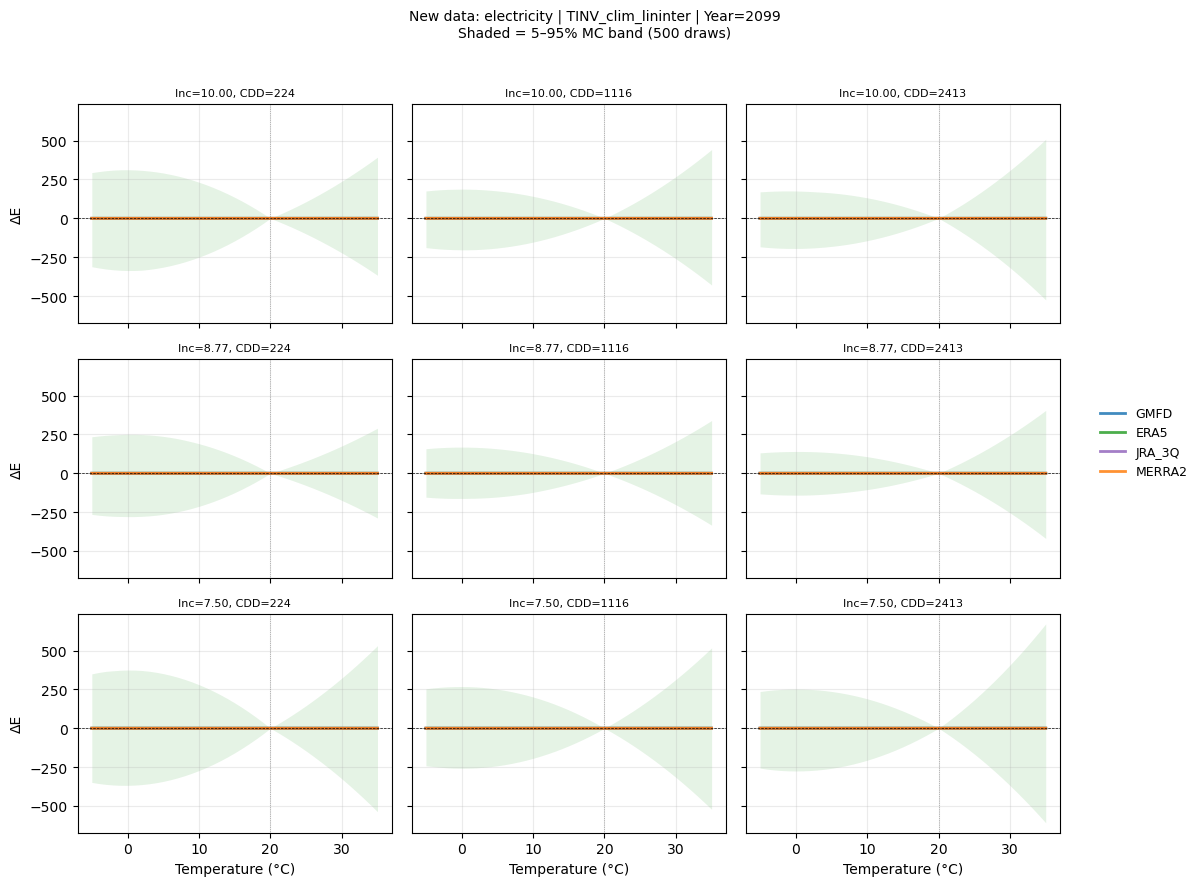

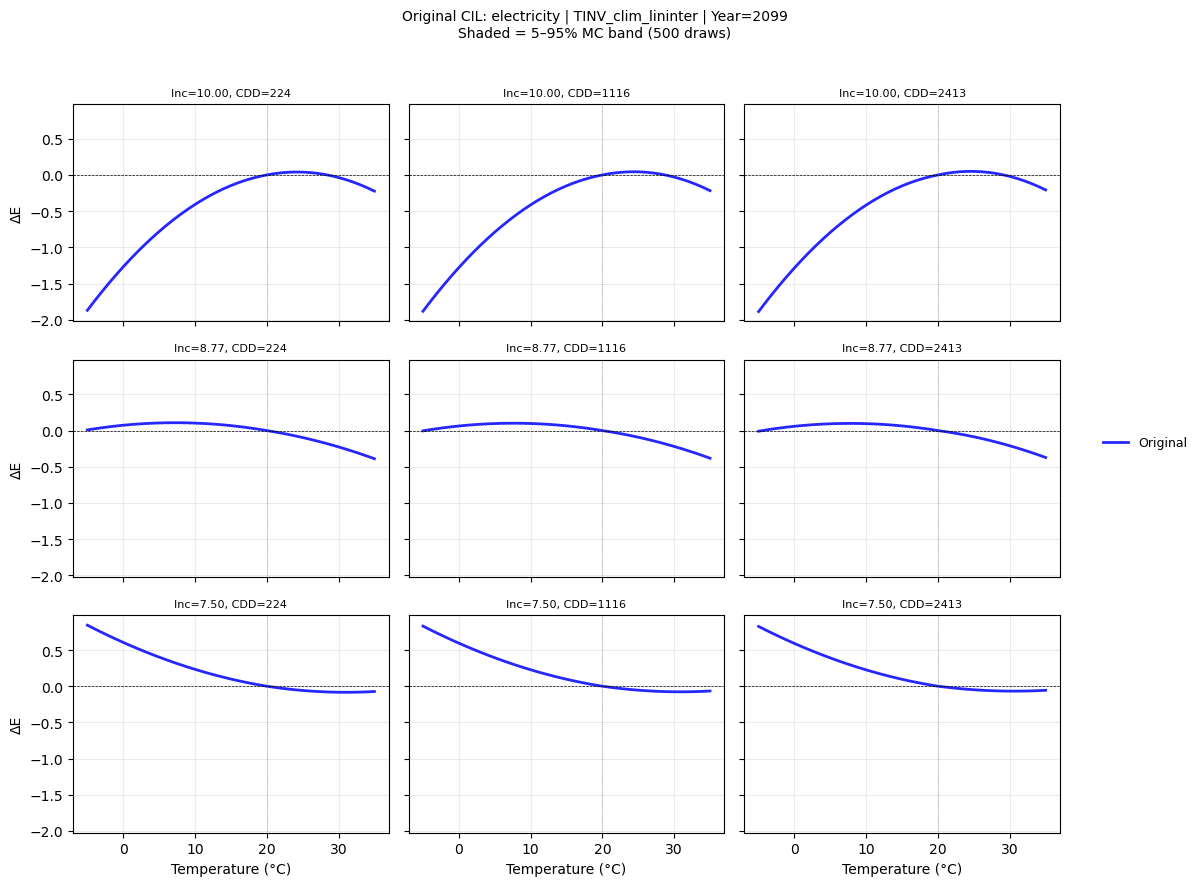

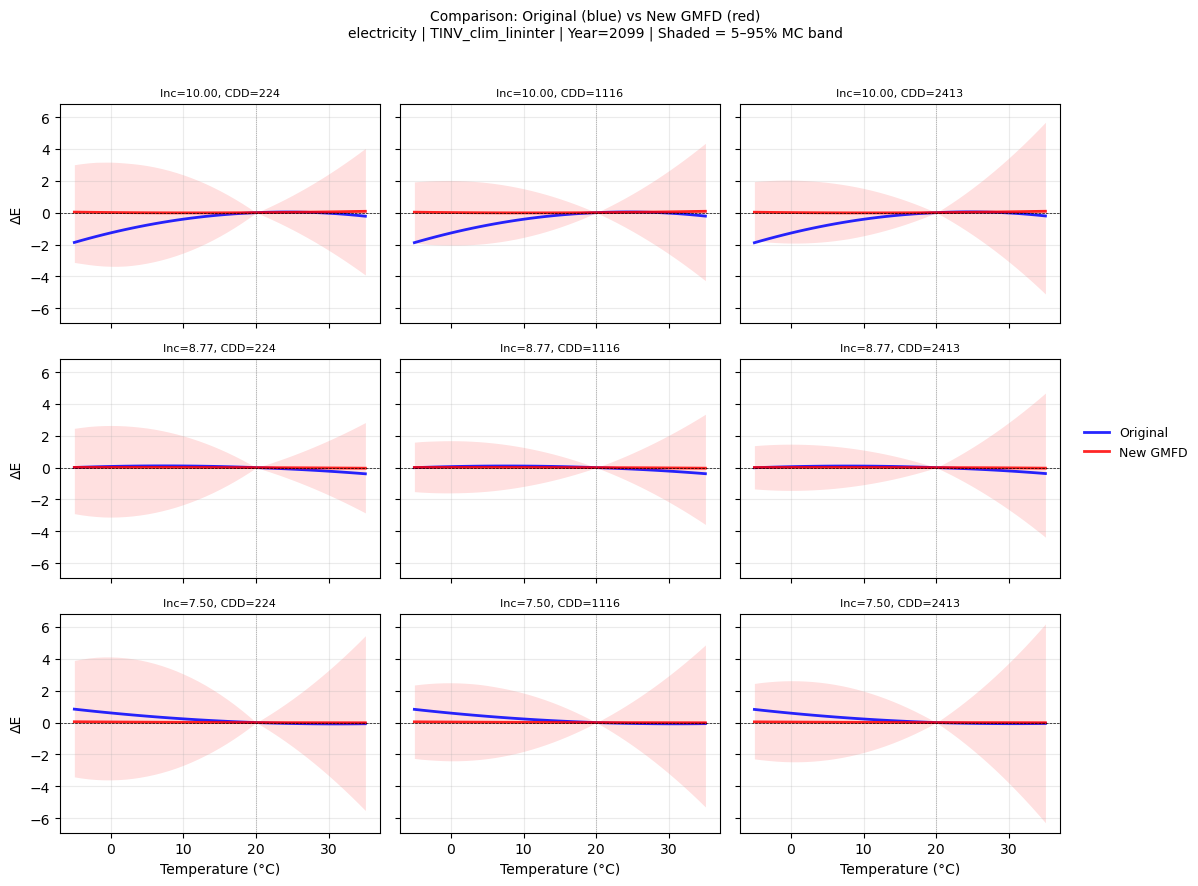

In [3]:
"""
plot_energy_response.py

Plots the energy-temperature response function from the Rode et al. (2021)
interacted FD specification (lininter), estimated across four observational
climate products (GMFD, ERA5, JRA-3Q, MERRA2).

Produces three figures:
  1. New data: 3x3 panel (income tercile x climate tercile) with all four
     products overlaid, with MC uncertainty bands.
  2. Original data: same panel layout using the CIL release coefficients,
     with MC uncertainty bands.
  3. Comparison: original (blue) vs new GMFD (red), with MC bands.

MC bands are drawn by sampling from MVN(beta_hat, V) using the exported
vcov CSV, constructing the response curve for each draw, and plotting
the 5th/95th percentile envelope across draws. Only parameters with
nonzero diagonal variance are included in the draw — omitted/collinear
terms (which have zero variance rows/cols in V) are held at their point
estimate values.

Inputs
------
- Per-product coefficient CSVs:
    NEW_STER / FD_FGLS_inter_{MODEL_NAME}_{product}_coeff.csv
- Per-product vcov CSVs (long format: parm_i, parm_j, v):
    NEW_STER / FD_FGLS_inter_{MODEL_NAME}_{product}_vcov_long.csv
- Original CIL coefficient CSV:
    ORIG_STER / FD_FGLS_inter_{MODEL_NAME}_coeff.csv
- Original CIL vcov CSV (if available):
    ORIG_STER / FD_FGLS_inter_{MODEL_NAME}_vcov_long.csv
- Break data:
    BREAK_DATA (see PATHS section below)
"""

import numpy as np
import pandas as pd
from pathlib import Path
import matplotlib.pyplot as plt

# ============================================================
# PATHS
# ============================================================
EU  = Path("/user/ab5405/summeraliaclimate/code/energy_uncertainty")
EDR = Path("/user/ab5405/summeraliaclimate/code/energy_consumption/"
           "energy_data_release_2021oct21")

NEW_STER   = EU / "data" / "regression" / "sters"
ORIG_STER  = EU / "output_original" / "sters"
BREAK_DATA = EDR / "DATA" / "regression" / "break_data_TINV_clim.dta"

OUTDIR = EU / "figures" / "comparison"
OUTDIR.mkdir(parents=True, exist_ok=True)

# ============================================================
# SETTINGS
# ============================================================
FUEL       = "electricity"        # "electricity" or "other_energy"
YEAR_PLOT  = 2099                 # year at which to evaluate temp×year terms
MODEL_TYPE = "interacted"
MODEL_NAME = "TINV_clim_lininter" # must match Stata local model_name

# MC uncertainty bands
N_DRAWS = 500                     # number of MVN draws; 500 is fast, 2000 smoother
RNG     = np.random.default_rng(42)
CI_LO   = 5                       # lower percentile
CI_HI   = 95                      # upper percentile

T       = np.arange(-5, 36, 1.0)
ABOVE20 = (T >= 20).astype(float)
BELOW20 = (T  < 20).astype(float)

# Colors for the four new-pipeline products
PROD_COLORS = {
    "GMFD":   "#1f77b4",
    "ERA5":   "#2ca02c",
    "JRA_3Q": "#9467bd",
    "MERRA2": "#ff7f0e",
}

# ============================================================
# I/O HELPERS
# ============================================================

def read_coeff_csv(path: Path) -> pd.Series:
    """
    Read coefficient CSV (columns: parm, beta) exported from Stata.
    Strips whitespace from parameter names since Stata sometimes pads them.
    Returns a Series indexed by parameter name.
    """
    df = pd.read_csv(path)
    df["parm"] = df["parm"].str.strip()
    return pd.Series(df["beta"].values, index=df["parm"].values)


def read_vcov_csv(path: Path) -> tuple[np.ndarray, list[str]]:
    """
    Read long-format vcov CSV (columns: parm_i, parm_j, v) exported from Stata.
    Reconstructs the square variance-covariance matrix.

    Returns
    -------
    V     : np.ndarray of shape (K, K)
    names : ordered list of K parameter names (row = column order)
    """
    df = pd.read_csv(path)
    df["parm_i"] = df["parm_i"].str.strip()
    df["parm_j"] = df["parm_j"].str.strip()

    # Preserve original row order for parameter ordering
    names = list(dict.fromkeys(df["parm_i"].tolist()))
    K     = len(names)
    idx   = {n: i for i, n in enumerate(names)}

    V = np.zeros((K, K))
    for _, row in df.iterrows():
        i = idx.get(row["parm_i"])
        j = idx.get(row["parm_j"])
        if i is not None and j is not None:
            V[i, j] = row["v"]

    return V, names


def get_coeff(coef: pd.Series, name: str, default: float = 0.0) -> float:
    """
    Look up a coefficient by name. Returns default (0.0) if not found.
    Missing terms contribute 0 to the response — correct for omitted/collinear
    terms. If curves look wrong, print coef.index to check naming mismatches.
    """
    return float(coef[name]) if name in coef.index else float(default)


def ibar_from_breakdata(bd: pd.DataFrame, fuel: str) -> float:
    """
    Income spline knot: maximum log income of large income group 1
    for the given fuel type. All dc1 terms are relative to this knot.
    """
    return float(
        bd.loc[bd[f"largegpid_{fuel}"] == 1, f"maxInc_largegpid_{fuel}"].max()
    )


def get_tercile_means(bd: pd.DataFrame) -> tuple[dict, dict, dict]:
    """
    Population-weighted tercile means from break_data.

    Returns dicts keyed by tercile ID:
      cdd_means : mean long-run CDD20 by tpid (1=coldest, 3=hottest)
      hdd_means : mean long-run HDD20 by tpid
      inc_means : mean log GDP pc by tgpid (1=lowest, 3=highest)

    Verify tpid ordering matches the Stata sort (sort tpid tgpid, index by
    tr*3) before trusting cell assignments.
    """
    cdd_means = bd.groupby("tpid")["avgCDD_tpid"].mean().to_dict()
    hdd_means = bd.groupby("tpid")["avgHDD_tpid"].mean().to_dict()
    inc_means = bd.groupby("tgpid")["avgInc_tgpid"].mean().to_dict()
    return cdd_means, hdd_means, inc_means


# ============================================================
# RESPONSE FUNCTION
# ============================================================

def _response_from_beta(
    beta:   np.ndarray,
    names:  list[str],
    fuel:   str,
    subInc: float,
    subCDD: float,
    subHDD: float,
    ibar:   float,
    year:   int,
    suffix: str,
    max_k:  int,
) -> np.ndarray:
    """
    Evaluate the interacted response curve given a flat beta vector.
    Used for both point estimates and individual MC draws.

    For each polynomial order k the response at temperature T is:
        y(T) = b_temp  * (T^k - 20^k)
             + above20 * b_cdd * subCDD * (T^k - 20^k)    [cooling heterogeneity]
             + below20 * b_hdd * subHDD * (20^k - T^k)    [heating heterogeneity]
             + b_dc1   * deltacut * (T^k - 20^k)          [income spline]
             + b_yt    * year * (T^k - 20^k)              [linear time trend]
             + b_dc1y  * deltacut * year * (T^k - 20^k)   [income x year]

    All terms are normalized to pass through 0 at T=20°C, consistent with
    the original Stata plotting script which uses (temp^k - 20^k).

    Parameters
    ----------
    suffix : "" for new pipeline (unsuffixed FD vars),
             "_GMFD" for original CIL (product embedded in var names)
    max_k  : 2 matches the original Stata plotting script (regression
             uses k=1..4 but Figure 1C plots only k=1..2)
    """
    coef = pd.Series(beta, index=names)

    pg       = 1 if fuel == "electricity" else 2
    ig       = 2 if subInc > ibar else 1
    deltacut = subInc - ibar

    y = np.zeros_like(T, dtype=float)

    for k in range(1, max_k + 1):
        Tk       = T ** k
        dT       = Tk - (20.0 ** k)
        dT_below = (20.0 ** k) - Tk

        b_temp = get_coeff(coef, f"c.indp{pg}#c.indf1#c.FD_temp{k}{suffix}")
        b_cdd  = get_coeff(coef, f"c.indp{pg}#c.indf1#c.FD_cdd20_TINVtemp{k}{suffix}")
        b_hdd  = get_coeff(coef, f"c.indp{pg}#c.indf1#c.FD_hdd20_TINVtemp{k}{suffix}")
        b_dc1  = get_coeff(coef, f"c.indp{pg}#c.indf1#c.FD_dc1_lgdppc_MA15I{ig}temp{k}")
        b_yt   = get_coeff(coef, f"c.indp{pg}#c.indf1#c.FD_yeartemp{k}{suffix}")
        b_dc1y = get_coeff(coef, f"c.indp{pg}#c.indf1#c.FD_dc1_lgdppc_MA15yearI{ig}temp{k}")

        y += b_temp  * dT
        y += ABOVE20 * b_cdd  * subCDD * dT
        y += BELOW20 * b_hdd  * subHDD * dT_below
        y += b_dc1   * deltacut        * dT
        y += b_yt    * year            * dT
        y += b_dc1y  * deltacut * year * dT

    return y


def yhat_interacted(
    coef:   pd.Series,
    fuel:   str,
    subInc: float,
    subCDD: float,
    subHDD: float,
    ibar:   float,
    year:   int,
    suffix: str = "",
    max_k:  int = 2,
) -> np.ndarray:
    """Point-estimate wrapper around _response_from_beta."""
    return _response_from_beta(
        coef.values, list(coef.index),
        fuel, subInc, subCDD, subHDD, ibar, year, suffix, max_k
    )


# ============================================================
# MC BANDS
# ============================================================

def mc_bands(
    coef:    pd.Series,
    V:       np.ndarray,
    vnames:  list[str],
    fuel:    str,
    subInc:  float,
    subCDD:  float,
    subHDD:  float,
    ibar:    float,
    year:    int,
    suffix:  str = "",
    max_k:   int = 2,
    n_draws: int = N_DRAWS,
    rng:     np.random.Generator = RNG,
) -> tuple[np.ndarray, np.ndarray, np.ndarray]:
    """
    Draw n_draws samples from MVN(beta_hat, V) and return the mean
    response and CI_LO/CI_HI percentile bands.

    Only parameters with nonzero diagonal variance are included in the
    MVN draw — omitted terms (zero variance rows/cols in V) are held at
    their point estimate. This avoids near-singularity issues from the
    full parameter matrix which includes precipitation, income dummies,
    and other terms outside the response function.

    Returns (y_mean, y_lo, y_hi), each of shape (len(T),).
    Falls back to the point estimate with flat bands if the draw fails.
    """
    v_idx  = {n: i for i, n in enumerate(vnames)}

    # Restrict to params present in both coef and V with nonzero variance
    active = [
        n for n in vnames
        if n in coef.index
        and n in v_idx
        and V[v_idx[n], v_idx[n]] != 0.0
    ]

    if not active:
        y_pt = yhat_interacted(coef, fuel, subInc, subCDD, subHDD,
                               ibar, year, suffix, max_k)
        print("  [WARN] No active parameters in vcov — returning point estimate")
        return y_pt, y_pt, y_pt

    ai    = [v_idx[n] for n in active]
    V_sub = V[np.ix_(ai, ai)]
    V_sub = V_sub + np.eye(len(ai)) * 1e-12   # small regularization for PD

    mu = np.array([coef.get(n, 0.0) for n in active])

    try:
        draws = rng.multivariate_normal(mu, V_sub, size=n_draws)
    except np.linalg.LinAlgError:
        y_pt = yhat_interacted(coef, fuel, subInc, subCDD, subHDD,
                               ibar, year, suffix, max_k)
        print("  [WARN] MVN draw failed — returning point estimate")
        return y_pt, y_pt, y_pt

    # Evaluate response for each draw, holding non-active params fixed
    base_coef = coef.copy()
    curves    = np.zeros((n_draws, len(T)))

    for i, draw in enumerate(draws):
        draw_coef = base_coef.copy()
        for name, val in zip(active, draw):
            draw_coef[name] = val
        curves[i] = _response_from_beta(
            draw_coef.values, list(draw_coef.index),
            fuel, subInc, subCDD, subHDD, ibar, year, suffix, max_k
        )

    return (
        np.mean(curves, axis=0),
        np.percentile(curves, CI_LO, axis=0),
        np.percentile(curves, CI_HI, axis=0),
    )


# ============================================================
# PLOTTING HELPER
# ============================================================

def plot_3x3(
    coef_dict:   dict,
    vcov_dict:   dict,
    suffix_dict: dict,
    color_dict:  dict,
    title:       str,
) -> plt.Figure:
    """
    Draw a 3x3 income x climate panel, overlaying all entries in coef_dict.
    MC bands are drawn for any label present in vcov_dict.

    Row order: high income (lg=3) top, low (lg=1) bottom.
    Col order: hot climate (tr=3) left, cold (tr=1) right.
    Matches original Stata: forval lg=3(-1)1, forval tr=3(-1)1.
    """
    fig, axes = plt.subplots(3, 3, figsize=(12, 9), sharex=True, sharey=True)
    fig.suptitle(title, y=0.98, fontsize=10)

    legend_handles = []
    legend_labels  = []

    for r, lg in enumerate([3, 2, 1]):
        for c, tr in enumerate([3, 2, 1]):
            ax     = axes[r, c]
            subInc = inc_means[lg]
            subCDD = cdd_means[tr]
            subHDD = hdd_means[tr]

            for label, coef in coef_dict.items():
                suffix = suffix_dict.get(label, "")
                color  = color_dict.get(label, "black")

                y_pt = yhat_interacted(
                    coef, FUEL, subInc, subCDD, subHDD,
                    ibar, YEAR_PLOT, suffix=suffix
                )
                ln, = ax.plot(T, y_pt, linewidth=2, color=color, alpha=0.85)

                if label in vcov_dict:
                    V, vnames = vcov_dict[label]
                    _, y_lo, y_hi = mc_bands(
                        coef, V, vnames, FUEL,
                        subInc, subCDD, subHDD,
                        ibar, YEAR_PLOT, suffix=suffix
                    )
                    ax.fill_between(T, y_lo, y_hi,
                                    color=color, alpha=0.12, linewidth=0)

                if r == 0 and c == 0 and label not in legend_labels:
                    legend_handles.append(ln)
                    legend_labels.append(label)

            ax.axhline(0,  color="black", linewidth=0.5, linestyle="--")
            ax.axvline(20, color="gray",  linewidth=0.5, linestyle=":")
            ax.set_title(f"Inc={subInc:.2f}, CDD={subCDD:.0f}", fontsize=8)
            ax.grid(True, alpha=0.25)

            if c == 0:
                ax.set_ylabel("ΔE", fontsize=10)
            if r == 2:
                ax.set_xlabel("Temperature (°C)", fontsize=10)

    if legend_handles:
        fig.legend(legend_handles, legend_labels,
                   loc="center right", frameon=False, fontsize=9)
        plt.tight_layout(rect=[0, 0, 0.90, 0.96])
    else:
        plt.tight_layout(rect=[0, 0, 1, 0.96])

    return fig


# ============================================================
# LOAD DATA
# ============================================================
print("Loading break_data...")
bd = pd.read_stata(BREAK_DATA)

ibar                            = ibar_from_breakdata(bd, FUEL)
cdd_means, hdd_means, inc_means = get_tercile_means(bd)

print(f"Income knot (ibar): {ibar:.4f}")
print(f"CDD means by tpid:  {cdd_means}")
print(f"HDD means by tpid:  {hdd_means}")
print(f"Inc means by tgpid: {inc_means}")

# ============================================================
# LOAD NEW COEFFICIENTS + VCOV
# ============================================================
print("\n" + "=" * 60)
print("LOADING NEW DATA")
print("=" * 60)

products_new = ["GMFD", "ERA5", "JRA_3Q", "MERRA2"]
coefs_new = {}
vcovs_new = {}

for prod in products_new:
    coef_path = NEW_STER / f"FD_FGLS_inter_{MODEL_NAME}_{prod}_coeff.csv"
    vcov_path = NEW_STER / f"FD_FGLS_inter_{MODEL_NAME}_{prod}_vcov_long.csv"

    if coef_path.exists():
        coefs_new[prod] = read_coeff_csv(coef_path)
        print(f"  {prod} coefficients: {len(coefs_new[prod])} terms")
    else:
        print(f"  WARNING: {coef_path.name} not found")

    if vcov_path.exists():
        V, vnames = read_vcov_csv(vcov_path)
        if np.any(V != 0):
            vcovs_new[prod] = (V, vnames)
            print(f"  {prod} vcov: {V.shape[0]}x{V.shape[1]}, trace={np.trace(V):.4f}")
        else:
            print(f"  WARNING: {prod} vcov is all zeros — MC bands omitted")
    else:
        print(f"  WARNING: {vcov_path.name} not found — MC bands omitted")

# ============================================================
# LOAD ORIGINAL COEFFICIENTS + VCOV
# ============================================================
print("\n" + "=" * 60)
print("LOADING ORIGINAL DATA")
print("=" * 60)

coef_orig   = None
vcov_orig   = None
suffix_orig = ""

orig_coef_path = ORIG_STER / f"FD_FGLS_inter_{MODEL_NAME}_coeff.csv"
orig_vcov_path = ORIG_STER / f"FD_FGLS_inter_{MODEL_NAME}_vcov_long.csv"

if orig_coef_path.exists():
    coef_orig   = read_coeff_csv(orig_coef_path)
    has_suffix  = any("_GMFD" in n for n in coef_orig.index)
    suffix_orig = "_GMFD" if has_suffix else ""
    print(f"  Original coefficients: {len(coef_orig)} terms, suffix={suffix_orig!r}")
else:
    print(f"  WARNING: {orig_coef_path.name} not found")

if orig_vcov_path.exists():
    V, vnames = read_vcov_csv(orig_vcov_path)
    if np.any(V != 0):
        vcov_orig = (V, vnames)
        print(f"  Original vcov: {V.shape[0]}x{V.shape[1]}, trace={np.trace(V):.4f}")
    else:
        print(f"  WARNING: original vcov is all zeros — MC bands omitted")
else:
    print(f"  WARNING: {orig_vcov_path.name} not found — MC bands omitted")

# ============================================================
# PLOT 1 — NEW DATA
# ============================================================
if coefs_new:
    print(f"\nPlotting new data ({N_DRAWS} MC draws)...")
    fig1 = plot_3x3(
        coef_dict   = coefs_new,
        vcov_dict   = vcovs_new,
        suffix_dict = {p: "" for p in products_new},
        color_dict  = PROD_COLORS,
        title       = (f"New data: {FUEL} | {MODEL_NAME} | Year={YEAR_PLOT}\n"
                       f"Shaded = {CI_LO}–{CI_HI}% MC band ({N_DRAWS} draws)"),
    )
    out1 = OUTDIR / f"NEW_all_products_{FUEL}_{MODEL_NAME}.pdf"
    fig1.savefig(out1)
    print(f"Saved: {out1.name}")

# ============================================================
# PLOT 2 — ORIGINAL DATA
# ============================================================
if coef_orig is not None:
    print(f"\nPlotting original data ({N_DRAWS} MC draws)...")
    fig2 = plot_3x3(
        coef_dict   = {"Original": coef_orig},
        vcov_dict   = {"Original": vcov_orig} if vcov_orig else {},
        suffix_dict = {"Original": suffix_orig},
        color_dict  = {"Original": "blue"},
        title       = (f"Original CIL: {FUEL} | {MODEL_NAME} | Year={YEAR_PLOT}\n"
                       f"Shaded = {CI_LO}–{CI_HI}% MC band ({N_DRAWS} draws)"),
    )
    out2 = OUTDIR / f"ORIGINAL_{FUEL}_{MODEL_NAME}.pdf"
    fig2.savefig(out2)
    print(f"Saved: {out2.name}")

# ============================================================
# PLOT 3 — COMPARISON
# ============================================================
if "GMFD" in coefs_new and coef_orig is not None:
    print(f"\nPlotting comparison ({N_DRAWS} MC draws)...")
    comp_vcovs = {}
    if vcov_orig:
        comp_vcovs["Original"] = vcov_orig
    if "GMFD" in vcovs_new:
        comp_vcovs["New GMFD"] = vcovs_new["GMFD"]

    fig3 = plot_3x3(
        coef_dict   = {"Original": coef_orig, "New GMFD": coefs_new["GMFD"]},
        vcov_dict   = comp_vcovs,
        suffix_dict = {"Original": suffix_orig, "New GMFD": ""},
        color_dict  = {"Original": "blue", "New GMFD": "red"},
        title       = (f"Comparison: Original (blue) vs New GMFD (red)\n"
                       f"{FUEL} | {MODEL_NAME} | Year={YEAR_PLOT} | "
                       f"Shaded = {CI_LO}–{CI_HI}% MC band"),
    )
    out3 = OUTDIR / f"COMPARISON_GMFD_{FUEL}_{MODEL_NAME}.pdf"
    fig3.savefig(out3)
    print(f"Saved: {out3.name}")

print("\n" + "=" * 60)
print("ALL DONE")
print("=" * 60)
print(f"Figures saved to: {OUTDIR}")
plt.show()

In [ ]:
import numpy as np
import pandas as pd
from pathlib import Path

# ============================================================
# PATHS
# ============================================================
EU = Path("/user/ab5405/summeraliaclimate/code/energy_uncertainty")
EDR = Path("/user/ab5405/summeraliaclimate/code/energy_consumption/energy_data_release_2021oct21")

NEW_STER = EU / "data" / "regression" / "sters"
ORIG_STER = EU / "output_original/sters"
BREAK_DATA = EDR / "DATA" / "regression" / "break_data_TINV_clim.dta"

MODEL_NAME = "TINV_clim_lininter"
FUEL = "electricity"
YEAR_PLOT = 2099

# ============================================================
# HELPERS
# ============================================================
def read_coeff_csv(path: Path) -> pd.Series:
    df = pd.read_csv(path)
    df["parm"] = df["parm"].str.strip()
    return pd.Series(df["beta"].values, index=df["parm"].values)

def get_coeff(coef: pd.Series, name: str, default=0.0) -> float:
    if name in coef.index:
        return float(coef[name])
    return float(default)

# ============================================================
# LOAD DATA
# ============================================================
print("Loading coefficients...")
coef_new = read_coeff_csv(NEW_STER / f"FD_FGLS_inter_{MODEL_NAME}_GMFD_coeff.csv")
coef_orig = read_coeff_csv(ORIG_STER / f"FD_FGLS_inter_{MODEL_NAME}_coeff.csv")

bd = pd.read_stata(BREAK_DATA)
maxcol = f"maxInc_largegpid_{FUEL}"
flagcol = f"largegpid_{FUEL}"
ibar = float(bd.loc[bd[flagcol] == 1, maxcol].max())

cdd_means = bd.groupby("tpid")["avgCDD_tpid"].mean().to_dict()
hdd_means = bd.groupby("tpid")["avgHDD_tpid"].mean().to_dict()
inc_means = bd.groupby("tgpid")["avgInc_tgpid"].mean().to_dict()

print(f"\nIncome knot (ibar): {ibar:.4f}")
print(f"Income means: {inc_means}")
print(f"CDD means: {cdd_means}")
print(f"HDD means: {hdd_means}")

# ============================================================
# DEBUG: Test at specific point (high income, hot climate)
# ============================================================
print("\n" + "="*70)
print("DEBUGGING AT: Inc=10.00, CDD=2413 (top-right panel)")
print("="*70)

subInc = inc_means[3]  # 10.00
subCDD = cdd_means[3]  # 2413
subHDD = hdd_means[3]  # Should be low for hot climate
pg = 1  # electricity
ig = 2 if subInc > ibar else 1
deltacut = subInc - ibar

print(f"\nSubstitution values:")
print(f"  subInc = {subInc:.4f}")
print(f"  subCDD = {subCDD:.0f}")
print(f"  subHDD = {subHDD:.0f}")
print(f"  ibar = {ibar:.4f}")
print(f"  deltacut = {deltacut:.4f}")
print(f"  income group (ig) = {ig}")
print(f"  product group (pg) = {pg}")

# Test at T = 30°C (should be positive)
T_test = 30.0
print(f"\n" + "="*70)
print(f"CALCULATION AT T = {T_test}°C")
print("="*70)

# ============================================================
# NEW GMFD
# ============================================================
print("\n" + "-"*70)
print("NEW GMFD (no suffix)")
print("-"*70)

y_new = 0.0
suffix = ""

for k in [1, 2]:
    print(f"\n--- k = {k} ---")
    
    Tk = T_test**k
    ref_k = 20.0**k
    dT = Tk - ref_k
    dT_below = ref_k - Tk
    
    print(f"T^{k} = {Tk:.4f}")
    print(f"20^{k} = {ref_k:.4f}")
    print(f"dT = {dT:.4f}")
    print(f"dT_below = {dT_below:.4f}")
    
    # Get all coefficients
    b_temp = get_coeff(coef_new, f"c.indp{pg}#c.indf1#c.FD_temp{k}{suffix}")
    b_cdd = get_coeff(coef_new, f"c.indp{pg}#c.indf1#c.FD_cdd20_TINVtemp{k}{suffix}")
    b_hdd = get_coeff(coef_new, f"c.indp{pg}#c.indf1#c.FD_hdd20_TINVtemp{k}{suffix}")
    b_dc1 = get_coeff(coef_new, f"c.indp{pg}#c.indf1#c.FD_dc1_lgdppc_MA15I{ig}temp{k}")
    b_yt = get_coeff(coef_new, f"c.indp{pg}#c.indf1#c.FD_yeartemp{k}{suffix}")
    b_dc1y = get_coeff(coef_new, f"c.indp{pg}#c.indf1#c.FD_dc1_lgdppc_MA15yearI{ig}temp{k}")
    b_y2t = get_coeff(coef_new, f"c.indp{pg}#c.indf1#c.FD_year2temp{k}{suffix}")
    b_dc1y2 = get_coeff(coef_new, f"c.indp{pg}#c.indf1#c.FD_dc1_lgdppc_MA15year2I{ig}temp{k}")
    
    print(f"\nCoefficients:")
    print(f"  b_temp   = {b_temp:.6e}")
    print(f"  b_cdd    = {b_cdd:.6e}")
    print(f"  b_hdd    = {b_hdd:.6e}")
    print(f"  b_dc1    = {b_dc1:.6e}")
    print(f"  b_yt     = {b_yt:.6e}")
    print(f"  b_dc1y   = {b_dc1y:.6e}")
    print(f"  b_y2t    = {b_y2t:.6e}")
    print(f"  b_dc1y2  = {b_dc1y2:.6e}")
    
    # Calculate contributions
    contrib_temp = b_temp * dT
    contrib_cdd = b_cdd * subCDD * dT if T_test >= 20 else 0
    contrib_hdd = b_hdd * subHDD * dT_below if T_test < 20 else 0
    contrib_dc1 = b_dc1 * deltacut * dT
    contrib_yt = b_yt * dT * YEAR_PLOT
    contrib_dc1y = b_dc1y * deltacut * YEAR_PLOT * dT
    contrib_y2t = b_y2t * dT * (YEAR_PLOT**2)
    contrib_dc1y2 = b_dc1y2 * deltacut * (YEAR_PLOT**2) * dT
    
    print(f"\nContributions to y:")
    print(f"  temp effect:     {contrib_temp:.6e}")
    print(f"  CDD effect:      {contrib_cdd:.6e}")
    print(f"  HDD effect:      {contrib_hdd:.6e}")
    print(f"  income spline:   {contrib_dc1:.6e}")
    print(f"  year*temp:       {contrib_yt:.6e}")
    print(f"  year*inc*temp:   {contrib_dc1y:.6e}")
    print(f"  year²*temp:      {contrib_y2t:.6e}")
    print(f"  year²*inc*temp:  {contrib_dc1y2:.6e}")
    
    contrib_k = (contrib_temp + contrib_cdd + contrib_hdd + contrib_dc1 + 
                 contrib_yt + contrib_dc1y + contrib_y2t + contrib_dc1y2)
    print(f"  TOTAL for k={k}:  {contrib_k:.6e}")
    
    y_new += contrib_k

print(f"\n{'='*70}")
print(f"FINAL y_new at T={T_test}°C: {y_new:.6f}")
print(f"{'='*70}")

# ============================================================
# ORIGINAL GMFD
# ============================================================
print("\n" + "-"*70)
print("ORIGINAL GMFD (with _GMFD suffix)")
print("-"*70)

y_orig = 0.0
suffix = "_GMFD"

for k in [1, 2]:
    print(f"\n--- k = {k} ---")
    
    Tk = T_test**k
    ref_k = 20.0**k
    dT = Tk - ref_k
    dT_below = ref_k - Tk
    
    # Get all coefficients
    b_temp = get_coeff(coef_orig, f"c.indp{pg}#c.indf1#c.FD_temp{k}{suffix}")
    b_cdd = get_coeff(coef_orig, f"c.indp{pg}#c.indf1#c.FD_cdd20_TINVtemp{k}{suffix}")
    b_hdd = get_coeff(coef_orig, f"c.indp{pg}#c.indf1#c.FD_hdd20_TINVtemp{k}{suffix}")
    b_dc1 = get_coeff(coef_orig, f"c.indp{pg}#c.indf1#c.FD_dc1_lgdppc_MA15I{ig}temp{k}")
    b_yt = get_coeff(coef_orig, f"c.indp{pg}#c.indf1#c.FD_yeartemp{k}{suffix}")
    b_dc1y = get_coeff(coef_orig, f"c.indp{pg}#c.indf1#c.FD_dc1_lgdppc_MA15yearI{ig}temp{k}")
    b_y2t = get_coeff(coef_orig, f"c.indp{pg}#c.indf1#c.FD_year2temp{k}{suffix}")
    b_dc1y2 = get_coeff(coef_orig, f"c.indp{pg}#c.indf1#c.FD_dc1_lgdppc_MA15year2I{ig}temp{k}")
    
    print(f"\nCoefficients:")
    print(f"  b_temp   = {b_temp:.6e}")
    print(f"  b_cdd    = {b_cdd:.6e}")
    print(f"  b_hdd    = {b_hdd:.6e}")
    print(f"  b_dc1    = {b_dc1:.6e}")
    
    # Calculate contributions
    contrib_temp = b_temp * dT
    contrib_cdd = b_cdd * subCDD * dT if T_test >= 20 else 0
    contrib_hdd = b_hdd * subHDD * dT_below if T_test < 20 else 0
    contrib_dc1 = b_dc1 * deltacut * dT
    contrib_yt = b_yt * dT * YEAR_PLOT
    contrib_dc1y = b_dc1y * deltacut * YEAR_PLOT * dT
    contrib_y2t = b_y2t * dT * (YEAR_PLOT**2)
    contrib_dc1y2 = b_dc1y2 * deltacut * (YEAR_PLOT**2) * dT
    
    print(f"\nContributions to y:")
    print(f"  temp effect:     {contrib_temp:.6e}")
    print(f"  CDD effect:      {contrib_cdd:.6e}")
    print(f"  income spline:   {contrib_dc1:.6e}")
    
    contrib_k = (contrib_temp + contrib_cdd + contrib_hdd + contrib_dc1 + 
                 contrib_yt + contrib_dc1y + contrib_y2t + contrib_dc1y2)
    print(f"  TOTAL for k={k}:  {contrib_k:.6e}")
    
    y_orig += contrib_k

print(f"\n{'='*70}")
print(f"FINAL y_orig at T={T_test}°C: {y_orig:.6f}")
print(f"{'='*70}")

print(f"\nDifference: {y_new - y_orig:.6f}")
print(f"Ratio: {y_new / y_orig:.2f}x" if y_orig != 0 else "")

# ============================================================
# Check what variable names actually exist
# ============================================================
print("\n" + "="*70)
print("CHECKING VARIABLE NAMES IN COEFFICIENT FILES")
print("="*70)

print("\nNEW GMFD - Income spline variables:")
for parm in coef_new.index:
    if "dc1_lgdppc" in parm:
        print(f"  {parm}: {coef_new[parm]:.6e}")

print("\nORIGINAL - Income spline variables:")
for parm in coef_orig.index:
    if "dc1_lgdppc" in parm:
        print(f"  {parm}: {coef_orig[parm]:.6e}")